<a href="https://colab.research.google.com/github/themehmi/Colab-Files/blob/main/Learning_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction**

Principal Component Analysis (PCA) is a dimensionality reduction technique used to simplify complex datasets while retaining as much information as possible. Imagine you are trying to take a 2D photograph of a 3D object; PCA helps you find the best angle for that photo so you don't lose the important details.

In data science, when you have dozens or hundreds of features (dimensions), PCA transforms them into a new set of variables called **Principal Components**.

### How It Works (The Intuition)

1.  **Finding the Direction of Maximum Variance:** PCA identifies the direction (the axis) along which the data varies the most. This becomes your **First Principal Component (PC1)**.
2.  **Orthonormality:** It then looks for the second direction, which must be at a right angle (90°) to the first, that contains the next highest amount of variation. This is **PC2**.
3.  **Dimension Reduction:** You can choose to keep only the top few components that capture, say, 95% of the data's "story," allowing you to discard the rest of the noisy or redundant dimensions.



### Why We Use It

* **Simplification:** It turns a 30-dimensional dataset (like the Breast Cancer data) into a 2D or 3D plot that a human can actually visualize and understand.
* **Speed:** Machine learning models run much faster on 5 principal components than they do on 50 raw features.
* **Removing Noise:** By ignoring components with very low variance, you often strip away random noise from your data, which can actually improve model accuracy.

### The "Golden Rule" of PCA: Scaling
Because PCA is a geographic approach based on distance and variance, you must **standardize** your data first. If one feature is measured in "kilometers" and another in "millimeters," the PCA will mistakenly think the kilometer-scale feature is more important simply because the numbers are larger.



### Mathematical Core
Mathematically, PCA relies on **Eigenvectors** and **Eigenvalues**.
* **Eigenvectors** determine the direction of the new axes.
* **Eigenvalues** determine the magnitude or "strength" of the variance in those directions.

To find these, we typically calculate the **Covariance Matrix** of the data:
$$C = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})(x_i - \bar{x})^T$$

By solving for the roots of this matrix, we extract the components that define the structure of your data.

Are you looking to implement the mathematical steps in NumPy, or would you prefer a high-level explanation of how to interpret the results?



---



---

We will be testing it on **Breast Cancer Winconsin Dataset**



# **About Dataset**

The **Breast Cancer Wisconsin (Diagnostic)** dataset is a classic collection used to train models to distinguish between **Malignant** (cancerous) and **Benign** (non-cancerous) tumors. It is especially popular for PCA because it contains 30 highly correlated features.

### Core Dataset Details
* **Instances:** 569
* **Features:** 30 numeric predictive features
* **Target Classes:** 212 Malignant (M), 357 Benign (B)
* **Missing Values:** None (making it very beginner-friendly)

### Feature Breakdown
The data describes characteristics of cell nuclei from digitized images of a fine needle aspirate (FNA). There are 10 core morphological traits measured for each nucleus:

1.  **Radius:** Mean of distances from center to points on the perimeter.
2.  **Texture:** Standard deviation of gray-scale values.
3.  **Perimeter & Area:** Measurements of the tumor size.
4.  **Smoothness:** Local variation in radius lengths.
5.  **Compactness:** $\frac{\text{Perimeter}^2}{\text{Area} - 1.0}$
6.  **Concavity:** Severity of concave portions of the contour.
7.  **Concave Points:** Number of concave portions of the contour.
8.  **Symmetry & Fractal Dimension:** Geometric complexity of the cell.

**The "Statistical Triple":** For each of these 10 traits, the dataset provides the **Mean**, **Standard Error**, and **Worst** (mean of the three largest values). This is why there are $10 \times 3 = 30$ total features.

### Why it's the "PCA King"
This dataset is excellent for PCA because many features are mathematically related. For example, `mean area`, `mean perimeter`, and `mean radius` all essentially measure the same thing (size). PCA allows you to collapse these redundant features into a single "Size" component, significantly simplifying your model without losing the signal.

Are you planning to run a classification model like KNN or Random Forest on this after you've applied PCA?

# **Importing Necesarry Libraries and Loading Dataset**


In [117]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA # import PCA from sklearn.decomposition
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

df=pd.read_csv("https://raw.githubusercontent.com/themehmi/datasets/refs/heads/main/breast_cancer_wisconsin.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# **Data Preprocessing**

In [118]:
#encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis']) # 0: Malignant, 1: Benign

In [119]:
#dropping irrelavent columns
df.drop(['id'],axis=1,inplace=True)
df.drop(['Unnamed: 32'],axis=1,inplace=True)

In [120]:
#splitting target and feature
X=df.drop(['diagnosis'],axis=1)
y=df['diagnosis']

### **Standardization** (VERY IMPORTANT)

```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
```

Why?

* PCA is **variance-based**
* Features with larger scale dominate

So we transform:
[
X_{scaled} = \frac{X - \mu}{\sigma}
]

Now all features have:

* mean = 0
* std = 1

---

In [121]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **PCA Transformation**

What PCA does internally:

1. Compute covariance matrix
2. Find eigenvectors & eigenvalues
3. Sort by highest variance
4. Project data onto top directions

You reduce:

```
4D → 2D

The core mechanism is to calculate the **covariance matrix** of your data and then perform an **eigen-decomposition**. The eigenvectors of that covariance matrix are the **principal components**. You *order them by their eigenvalues*, which indicate h*ow much variance each component explains*. After projecting the data onto these top components, **you get a lower-dimensional representation with minimal information loss**.

---

###What is a Covariance Matrix?
In simple terms, **Covariance** measures how two variables move together.
* If "Cell Area" goes up when "Cell Radius" goes up, they have **high covariance**.
* The **Covariance Matrix** is just a grid that shows the relationship between every possible pair of features in your dataset (e.g., Radius vs. Area, Texture vs. Symmetry). It tells PCA where the "redundant" information is.

---

###Eigen-decomposition: The "Simplifier"
**Eigen-decomposition** is a mathematical tool that takes a complex matrix and breaks it down into its most basic, fundamental parts. It’s like taking a complex chord in music and identifying the individual notes that make it up.

When we perform this on a Covariance Matrix, we are asking: *"In all this mess of data, what are the primary directions of movement?"*



---

###Eigenvectors and Eigenvalues
These two always come as a pair. Think of them as the **Direction** and the **Strength**.

#### **Eigenvectors (The Direction)**
An eigenvector is a **direction** or an axis. In PCA, the eigenvectors are the **Principal Components**.
* **The First Eigenvector** points exactly in the direction where the data is most stretched out (the longest part of the rock).
* **The Second Eigenvector** points in the next most stretched direction, but it must be at a 90-degree angle to the first.

#### **Eigenvalues (The Strength/Importance)**
An eigenvalue is a **number** that tells you how much "action" (variance) is happening in that eigenvector's direction.
* A **Large Eigenvalue** means that direction captures a lot of information.
* A **Small Eigenvalue** means that direction is mostly "noise" or unimportant detail.



---

Putting it All Together
1.  **Calculate Covariance:** You map out how all your features (like cell size and texture) relate.
2.  **Eigen-decompose:** You break that map down to find the fundamental directions (**Eigenvectors**) and their importance (**Eigenvalues**).
3.  **Sort and Pick:** You rank them by the Eigenvalues. You keep the top 2 or 3 and throw away the rest.
4.  **Project:** You "squash" your 30D data onto these 2 or 3 new axes.

**The Result:** You now have a simple 2D graph that still shows the "true shape" of your 30D cancer data, making it easy to see the difference between sick and healthy cells.

In [122]:
# Apply PCA (reduce to 2 components)
pca = PCA(n_components=2)
# pca = PCA(n_components=0.95)  # adaptive
X_pca = pca.fit_transform(X_scaled)

In [123]:
X_pca

array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       ...,
       [ 1.25617928, -1.90229671],
       [10.37479406,  1.67201011],
       [-5.4752433 , -0.67063679]])

In PCA, **`n_components`** is the parameter that tells the algorithm how many dimensions you want to keep after the transformation. It is the "knob" you turn to decide how much you want to simplify your data.

When you use a tool like `scikit-learn`, `n_components` can be set in three different ways depending on your goal:

### 1. Setting a Specific Number (Integer)
If you set `n_components=2`, you are telling the computer: "I don't care if there were 30 features or 3,000; I only want the top **2 Principal Components**."
* **Best for:** Visualization. Since we can only see in 2D or 3D, setting this to 2 or 3 allows you to plot your data on a standard graph.
* **The Trade-off:** You might lose important information if the first two components don't capture enough of the data's variance.



### 2. Setting a Variance Threshold (Float)
This is a "smarter" way to use PCA. If you set `n_components=0.95`, you are saying: "Keep as many components as **necessary** to explain **95%** of the original variance."
* **Best for:** Machine Learning preprocessing. It ensures you simplify the data as much as possible without losing the "signal" that your model needs to make accurate predictions.
* **Result:** The algorithm will automatically decide the number of components for you (e.g., it might find that 7 components are enough to represent 95% of your 30-feature dataset).

### 3. Keeping All Components (`None`)
If you don't specify `n_components`, it defaults to the total number of features.
* **Best for:** Initial Analysis. You do this when you want to create a **Scree Plot**. A Scree Plot shows you the explained variance for every possible component, helping you "see" where the elbow is so you can decide the best value for `n_components` later.



---

### How to choose the right `n_components`?
In your work with the **Breast Cancer Wisconsin** dataset, you would typically:
1.  Run PCA with `n_components=None`.
2.  Plot the **Cumulative Explained Variance**.
3.  Look for the "Elbow"—the point where adding more components doesn't give you much more information.

For that specific dataset, you'll usually find that while there are 30 features, an `n_components` of **5 or 6** is usually enough to capture almost all the important patterns.

Are you trying to decide on a specific number for a visualization, or are you looking to optimize a model's performance?



---



# **Visualisation**

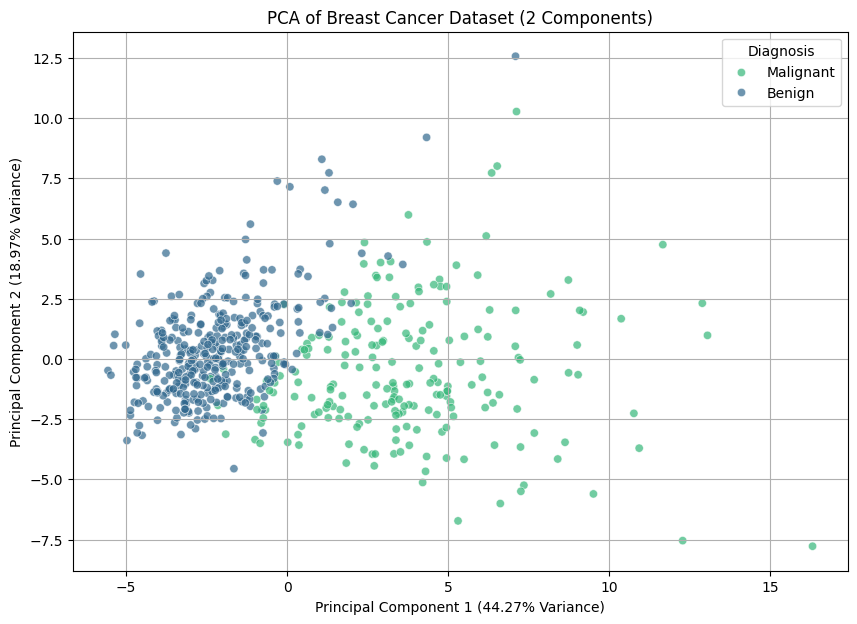

Total Variance Explained by 2 components: 63.24%


In [124]:
# Create a DataFrame for the new components
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Target'] = y

#plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Target', data=pca_df, palette='viridis', alpha=0.7)

plt.title('PCA of Breast Cancer Dataset (2 Components)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} Variance)')
plt.legend(title='Diagnosis', labels=['Malignant', 'Benign'])
plt.grid(True)
plt.show()

#check variance retention
print(f"Total Variance Explained by 2 components: {sum(pca.explained_variance_ratio_):.2%}")

# **Evaluating using KNeighborsClassifier**

In [125]:
#import library
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

**Before PCA**

In [126]:
X_train , X_test,y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model_bpca = KNeighborsClassifier()
model_bpca.fit(X_train, y_train)
y_pred_bpca = model_bpca.predict(X_test)
accuracy_bpca = accuracy_score(y_test, y_pred_bpca, normalize=True)
print(f"Accuracy before PCA: {accuracy_bpca:.2%}")

Accuracy before PCA: 94.74%


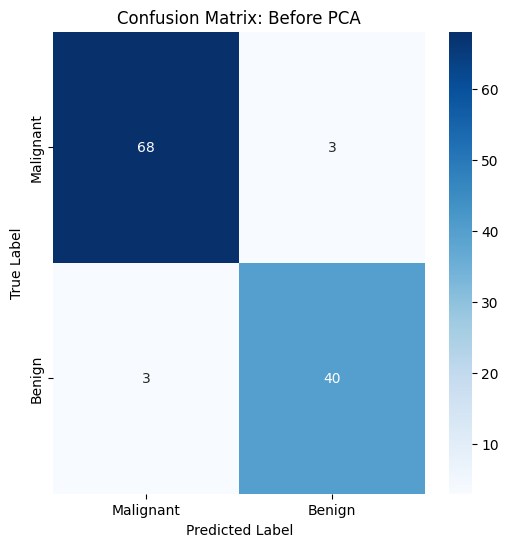

In [127]:
# Generating the confusion matrix
cm_bpca = confusion_matrix(y_test, y_pred_bpca)

# Visualizing using Seaborn
plt.figure(figsize=(6, 6))
sns.heatmap(cm_bpca, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix: Before PCA')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [128]:
#print classification report
print(classification_report(y_test, y_pred_bpca))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



**After PCA**

In [129]:
X_train , X_test,y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)
model_apca = KNeighborsClassifier()
model_apca.fit(X_train, y_train)
y_pred_apca = model_apca.predict(X_test)
accuracy_apca = accuracy_score(y_test, y_pred_apca, normalize=True)
print(f"Accuracy after PCA: {accuracy_bpca:.2%}")

Accuracy after PCA: 94.74%


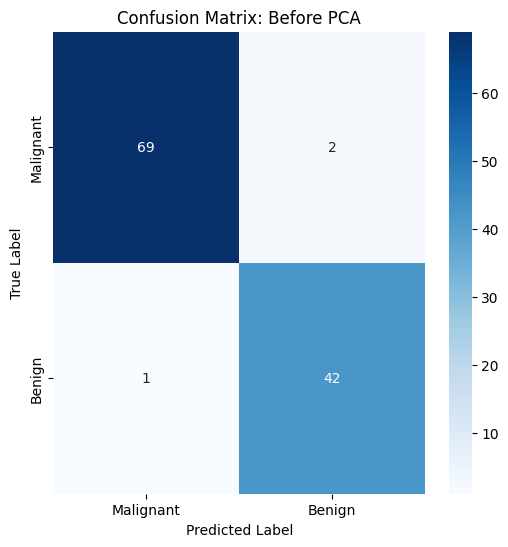

In [130]:
# Generating the confusion matrix
cm_apca = confusion_matrix(y_test, y_pred_apca)

# Visualizing using Seaborn
plt.figure(figsize=(6, 6))
sns.heatmap(cm_apca, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix: Before PCA')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [131]:
#print claasification report
print(classification_report(y_test, y_pred_apca))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



# **Original covariance versus the PCA covariance**

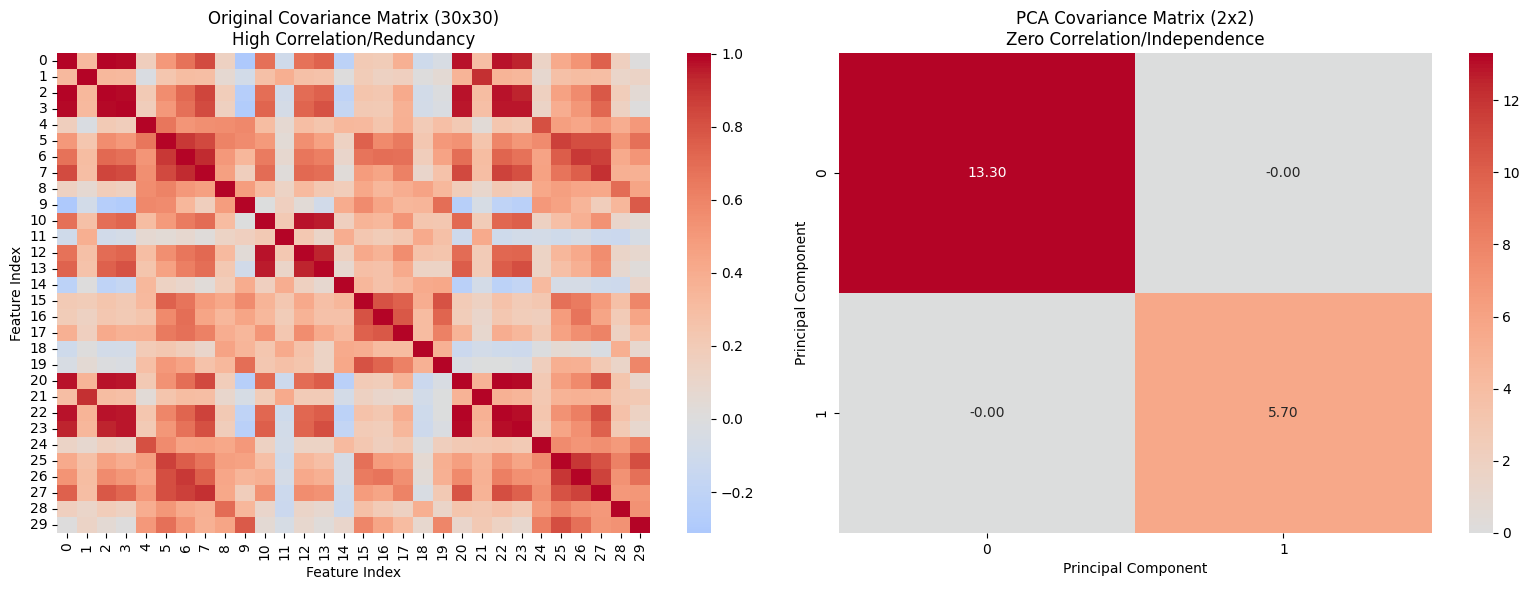

In [132]:
# We take the transpose (.T) because np.cov expects variables in rows
orig_cov = np.cov(X_scaled.T)

# 2. PCA Covariance (New Components)
pca_cov = np.cov(X_pca.T)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap for Original Covariance
sns.heatmap(orig_cov, cmap='coolwarm', ax=ax[0], center=0)
ax[0].set_title('Original Covariance Matrix (30x30)\nHigh Correlation/Redundancy')
ax[0].set_xlabel('Feature Index')
ax[0].set_ylabel('Feature Index')

# Heatmap for PCA Covariance
sns.heatmap(pca_cov, annot=True, fmt='.2f', cmap='coolwarm', ax=ax[1], center=0)
ax[1].set_title('PCA Covariance Matrix (2x2)\nZero Correlation/Independence')
ax[1].set_xlabel('Principal Component')
ax[1].set_ylabel('Principal Component')

plt.tight_layout()
plt.show()